# Thermodynamic diagrams
We create thermo diagrams as described in p.63, ch.3, 4 and 5 of the book by R. Stull *Practical Meteorology*

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

A thermo diagram contains, in addition to the pressure and temperature grid lines, also dry and wet adiabats that can help at intepreting the state of the atmosphere from the temperature profile. The dry adiabats can be drawn from the equation of the potential temperature as a function of pressure used as a proxy for the elevation
$$T_2 = T_1 \cdot \left ( \frac{p_2}{p_1}\right ) ^{\frac{R_d}{c_p}} $$

In [2]:
def p_theta(T, theta):
    '''
    This function computes the dry adiabat for the potential temperature
    (theta) given as argument.
    '''
    T_0 = 273.15
    K = T + T_0
    theta_k = theta + T_0
    R_d = 287.08 # J/(KgK) gas constant for dry air
    c_p = 1004 # J(KgK) specific heat for dry air at constant pressure
    p_0 = 100 # kPa 
    p = p_0 / (theta_k / K) ** (c_p / R_d)
    return p

## Dry adiabats
We collect a number of dry adiabats

In [3]:
t_diagrams = [] 
T = np.linspace(-60, 70)
for theta in range(-60,70, 10):
    p = p_theta(T, theta)
    t_diagrams.append(p)

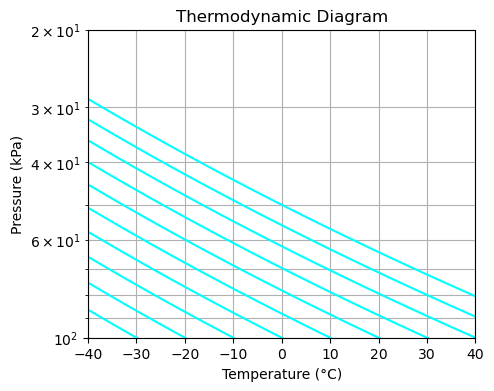

In [11]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.grid(visible=True, which='major')
ax.grid(axis='both', visible=True, which='minor')
ax.yaxis.set_inverted(True)
ax.set_ylim(100, 20)
ax.set_xlim(-60, 40)
ax.set_title("Thermodynamic Diagram")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (kPa)")
for i in range(0, len(t_diagrams)):
    ax.semilogy(T, t_diagrams[i], color='cyan', label='$\\theta = ' + str(i) + ' °C$')
    ax.set_xlim(-40, 40)
    #ax.text(T[i], t_diagrams[i][10] + 50, r'$\theta$')
    x = T[0] + i
    y = t_diagrams[i][10]
    ax.annotate('$\\theta = ' + str(i * 10) + '$', xy=(x, y), xytext=(x + 1.0, y + 0.8), rotation=0, size=8, color='red')
#ax.legend();

## Moisture variables
The water content in the atmosphere can be represented using several variables: mixing ratio, specific humidity, absolute humidity, relative humidity, dew point.

### Mixing ratio
While the mixing ratios of other gases in the atmosphere are well mixed and is constant with height, the water vapor mixing ratio $r$ can change in time and space. It is defined as the ratio of mass of water vapor to the mass of the dry air
$$r = \frac{m_v}{m_d}$$
where $m_v$ is the mass, in Kg of the water vapor and $m_d$ is the mass of dry air.

### $\epsilon$ ratio 
It is defined as the ratio between the dry air gas constant $R_d$ and the water vapor gas constant $R_v$
$$\epsilon = \frac{R_d}{R_v} = \frac{M_v}{M_d} = \frac{18.0}{28.96} = 0.6215$$
where $M_v$ is the water vapor molar mass, that is the mass of one mole of water molecules, and $M_d$ is the molar mass of dry air that is defined as a mixture of nitrogen, oxygen, argon.

### Conversion between mixing ratio and vapor pressure
We use the gas law for water vapor $e$ and for the air $p$. The total pressure of moist air is
$$P = p + e$$
For water vapor the gas law is
$$eV = \frac{m_w}{M_v}RT$$
and for dry air is
$$pV = \frac{m_d}{M_d}RT$$
From the last two equations we have
$$m_v = \frac{M_v eV}{RT}$$
and
$$m_d = \frac{M_d pV}{RT}$$
so that for the water vapor mixing ratio we have
$$r = \frac{e}{p} \frac{M_v}{M_d} = \frac{\epsilon e}{p} = \frac{\epsilon e}{P - e}$$
From the last expression we can calculate the vapor pressure from the water vapor mixing ratio and the pressure of the moist air
$$e = \frac{rP}{\epsilon + r}$$

### Specific humidity
The specifi humidity is similar to the water vapor mixing ration. It is defined as the ratio of the mass of water vapor $m_v$ to the mass of the moist air $m_a$
$$q = \frac{m_v}{m_a} = \frac{m_v}{m_d + m_v}$$

### Relative humidity
It is defined as the ratio between the water vapor pressure $e$ and its value at saturation $e_s$, usually in percentage
$$RH = \frac{e}{e_s} \times 100$$

### Virtual temperature
It is defined as the temperature of dry air when water vapor is taken into account. From the [Dalton's law of partial pressures](https://en.wikipedia.org/wiki/Dalton%27s_law) the pressure of moist air $P$ is the sum of the pressure of water vapor $e$ and that of dry air $p$
$$PV = (p + e)V = \frac{m_d}{M_d}RT + \frac{m_v}{M_v}RT = RT(\frac{m_d}{M_d} + \frac{m_v}{M_v})$$
and 
$$p + e = \frac{RT}{V} (\frac{m_d}{M_d} + \frac{m_v}{M_v})$$

The density $\rho$ of moist air is the sum of the densities of water vapor and dry air

$$\rho = \rho_v + \rho_d = \frac{m_v}{V} + \frac{m_d}{V} = \frac{m_v + m_d}{V}$$

so that 

$$\frac{1}{V} = \frac{\rho}{m_v + m_d}$$

and 

$$p + e = \rho RT \frac{\frac{m_d}{M_d} + \frac{m_v}{M_v}}{m_v + m_d}$$

From the definition of the water vapor mixing ratio $r$ we have

$$m_v = rm_d$$

From the definition of the ratio $\epsilon$

$$M_v = \epsilon M_d$$

Substituting these values into the expression of the Dalton's law we have

$$P = p + e = \rho \frac{R}{M_d}T \frac{1 + \frac{r}{\epsilon}}{1 + r}$$
Setting the gas constant for dry air
$$R' = \frac{R}{M_d}$$
and the temperature of moist air, also known as the *virtual temperature*
$$T_v = T \frac{1 + \frac{r}{\epsilon}}{1 + r}$$
we can write the equation of state for the moist air as
$$P = \rho R' T_v$$

### Dew point temperature $T_d$
By defiinition, it is the temperature $T_d$ to which moist air must be cooled, with pressure and water vapor mixing ratio held constant, for it to reach saturation with respect to water. It can be calculated analytically from the Clausius-Clapeyron equation

$$e = e_0 e^{\frac{\lambda M}{R}(\frac{1}{T_0} - \frac{1}{T_d})}$$

From the equation after some manipulation we get

$$ln\frac{e}{e_0} = \frac{\lambda M_v}{R}(\frac{1}{T_0} - \frac{1}{T_d})$$

and after setting

$$R_v = \frac{R}{M_v}$$

we have

$$T_d = [\frac{1}{T_0} - \frac{R_v}{\lambda} ln \frac{e}{e_0}]^{-1}$$

The dew point temperature can also be obtained from a tephigram. Starting from a point (p,T) in the thermo diagram one has to
1. Move along the adiabatic passing through (p,T) up to the isohume with the given mixing ratio 
2. Follow the isohume down to the given isobar at costant pressure p
3. Follow the isotherm down to the tenmperature axis

### Wet-bulb temperature $T_w$
By definition, it is the temperature to which moist air can be cooled at constant pressure by water evaporation until saturation is reached. From the 1st principle of Thermodynamics we have
$$c_pdT = - \lambda dw$$
where $dw$ is the element of mass of water lost by evaporation given as change in mixing ratio. Integrating both members of the equation we get
$$c_p(T-T_w) = -\lambda (w - w_s)$$
where $w_s$ is the saturated water. Manipulating the equation we get the wet-bulb temperature
$$T_w = T + \frac{\lambda}{c_p}(w -w_s)$$

### Lifting condensation level
The [lifting condensation level](https://en.wikipedia.org/wiki/Lifting_condensation_level) is the height at which a parcel of moist air becomes saturated with the condensation of water vapor and the formation of cloud drops.

In [2]:
from metpy.calc import lcl
from metpy.units import units

In [3]:
pressure = 1000 * units.hPa
temperature = 25 * units.degC
dewpoint = 15 * units.degC

In [4]:
lcl_pressure, lcl_temperature = lcl(pressure, temperature, dewpoint)

In [5]:
print(f"LCL Pressure: {lcl_pressure:.2f}")
print(f"LCL Temperature: {lcl_temperature:.2f}")

LCL Pressure: 862.87 hectopascal
LCL Temperature: 12.73 degree_Celsius


## Skew-T Log-P
The Skew T - Log P diagram is a thermodynamic diagram for the profile of atmospheric temperature as a function of pressure representing elevation. The temperature profile provides the state of the atmosphere: the inversion layers, the levels of water vapor condensation and, together with the wind profile at altitude and a terrain model, estimates of possible precipitation and its amount can be made. The graph is semilogarithmic and together with the pressure and temperature coordinates also reports the curves of the dry (yellow line) and wet adiabatics (purple line). In the figure is the graph of the temperature profile collected at 12:00 today 24 June 2026 by the Military Aeronautics in Pratica di Mare, one of the six Italian stations for the collection of atmospheric profiles. A temperature reversal is noted at 950 hPa (500 m.), then the profile follows dry adiabatics, without vapor condensation, and then from 500 hPa (5500 m.), after further reversals, follows a wet adiabaticity, indicating that condensation has occurred. From 200 hPa (12 km) the profile makes a sharp inversion, typical of the stratosphere. Knowing how to read these diagrams is of great importance for weather forecasting, especially in the short term.

In [11]:
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units

# 1. Generate or import sample sounding data
# Pressure must go from high (surface) to low (top of atmosphere)
p = np.array([1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100]) * units.hPa
T = np.array([25, 20, 15, 5, -12, -23, -41, -52, -55, -56, -54]) * units.degC
Td = np.array([18, 14, 8, -2, -22, -35, -55, -65, -73, -80, -85]) * units.degC

# Wind components for the barbs
wind_speed = np.array([10, 15, 20, 30, 45, 55, 70, 85, 90, 80, 60]) * units.knots
wind_dir = np.array([180, 190, 210, 230, 250, 260, 270, 270, 280, 280, 290]) * units.degrees
u, v = mpcalc.wind_components(wind_speed, wind_dir)

Instead of writing our own functions to plot the dry and moist adiabats we can use [MetPY](https://unidata.github.io/MetPy/latest/index.html) that provides functions to do just that.

In [55]:
def plot_skew(p, variables, labels, save_diagram=False):
    '''
    This function plots the temperature and the dew point profiles
    in a skew T log p diagram
    '''
    # 2. Set up the figure and SkewT object
    fig = plt.figure(figsize=(9, 9))
    # 'rotation=45' controls the slant of the temperature lines
    skew = SkewT(fig, rotation=45)

    # 3. Plot the environmental profiles
    # Note: MetPy requires (pressure, variable) order for plotting
    num_vars = len(variables)
    colors = ['r', 'g']
    for i in range(num_vars):
        skew.plot(p, variables[i], colors[i], linewidth=2, label=labels[i])
    #skew.plot(p, Td, 'g', linewidth=2, label='Dewpoint')

    # Plot LCL temperature as black dot
    #lcl_pressure, lcl_temperature = mpcalc.lcl(p[0], T[0], Td[0])
    #skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='black')
    
    # 4. Plot wind barbs on the right axis
    #skew.plot_barbs(p, u, v)

    # 5. Add standard thermodynamic background lines
    skew.plot_dry_adiabats(colors='orange', alpha=0.4, linewidths=1)
    skew.plot_moist_adiabats(colors='blue', alpha=0.4, linewidths=1)
    skew.plot_mixing_lines(colors='green', alpha=0.3, linewidths=1, linestyle=':')

    # 6. Customize axes limits and labels
    skew.ax.set_xlim(-40, 40)
    skew.ax.set_ylim(1050, 100) # Flipped so high pressure is at the bottom

    plt.title('Skew-T ln P Diagram', fontsize=14, fontweight='bold')
    for label in labels:
        skew.ax.set_xlabel(label)
        
    skew.ax.set_ylabel('Pressure (hPa)')
    skew.ax.legend();
    if (save_diagram == True):
        plt.savefig('data/skewTlnp_diagram.jpg')

In [58]:
variables = []
variables.append(T)
labels = []
labels.append('Temperature')

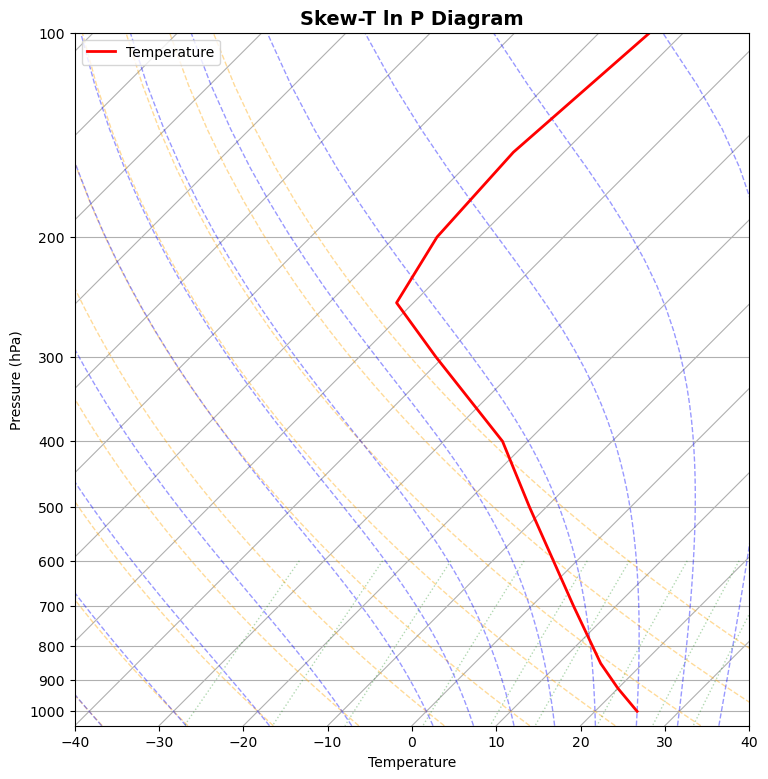

In [59]:
plot_skew(p, variables, labels)

In [42]:
radiosonde_path = 'data/pratica_di_mare/2026062412-16245.csv'
radiosonde_df = pd.read_csv(radiosonde_path, index_col=0)
radiosonde_df.head()

,geopotential height_m,temperature_C,dew point temperature_C,ice point temperature_C,relative humidity_%,humidity wrt ice_%,mixing ratio_g/kg,wind direction_degree,wind speed_m/s
pressure_hPa,,,,,,,,,
1012.0,32,31.8,20.8,20.8,52,52,15.45,250,2.1
1009.0,59,29.4,19.4,19.4,55,55,14.18,246,2.3
1002.0,122,29.0,19.0,19.0,55,55,13.92,238,2.9
1000.0,140,29.2,19.2,19.2,55,55,14.13,235,3.1
976.0,356,26.6,18.6,18.6,62,62,13.94,193,3.1


In [43]:
rs_pressure = radiosonde_df.index.to_numpy() * units.hPa

In [44]:
rs_temperature = radiosonde_df['temperature_C'].to_numpy() * units.degC

In [45]:
rs_dew_point = radiosonde_df['dew point temperature_C'].to_numpy() * units.degC

In [60]:
variables = []
variables.append(rs_temperature)
variables.append(rs_dew_point)
labels = []
labels.append('Temperature')
labels.append('Dew Point')

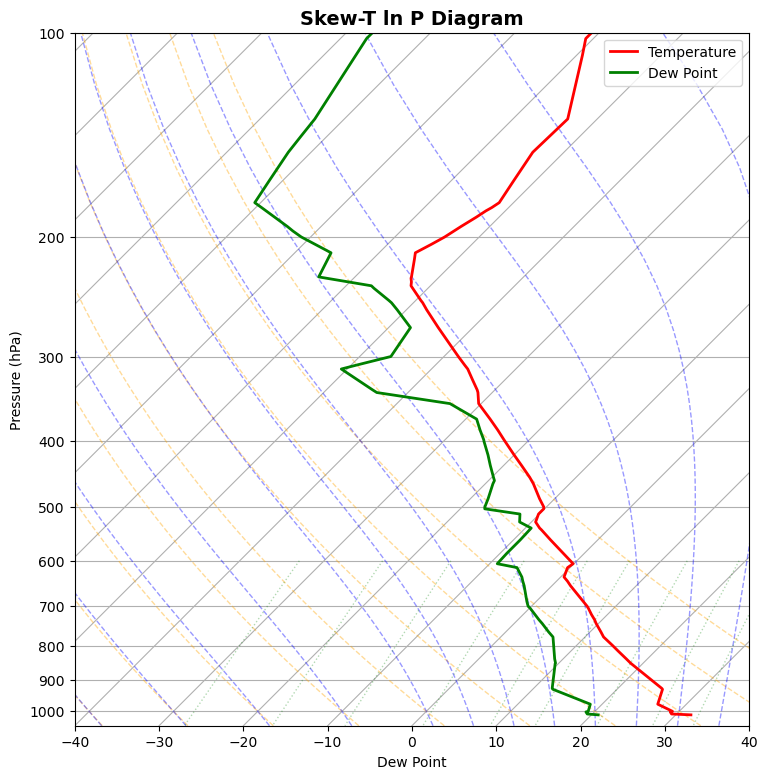

In [61]:
plot_skew(rs_pressure, variables, labels)

In [62]:
radiosonde_path_1 = 'data/pratica_di_mare/2026062312-16245.csv'
radiosonde_df_1 = pd.read_csv(radiosonde_path, index_col=0)

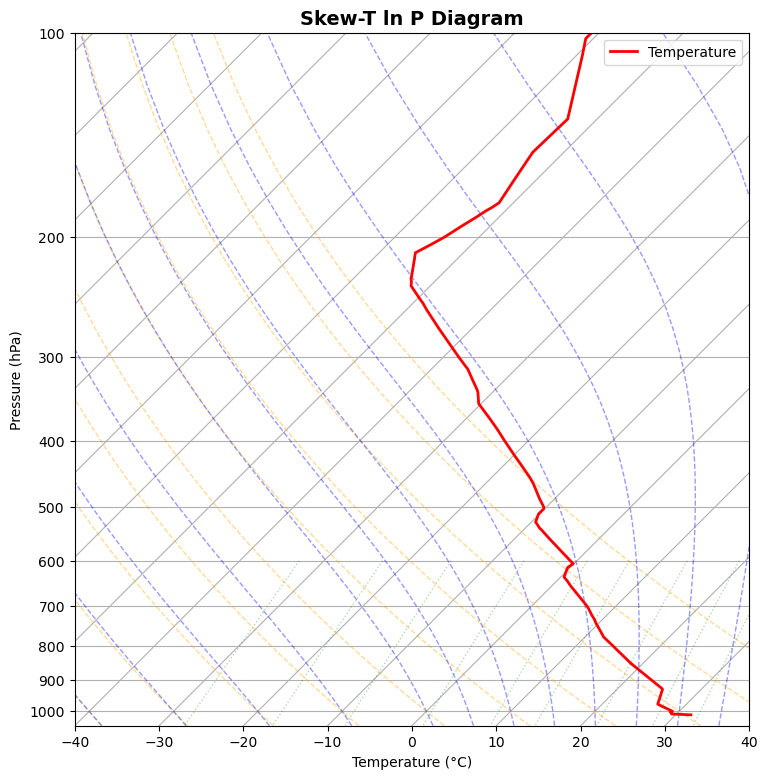

In [71]:
rs_pressure_1 = radiosonde_df_1.index.to_numpy() * units.hPa
rs_temperature_1 = radiosonde_df_1['temperature_C'].to_numpy() * units.degC
plot_thermodiagram(rs_pressure_1, rs_temperature_1, True)

## References and datasets
* [University of Wyoming Atmospheric Science Radiosonde Archive](https://weather.uwyo.edu/upperair/sounding.shtml)
* [Aeronautica Militare Italiana - Il Servizio di Radiosondaggio automatico dell'atmosfera](https://www.meteoam.it/it/autosonda)
* [VAISALA - Radiosonde RS41-SG](https://docs.vaisala.com/v/u/B211321EN-L/en-US)
* [Copernicus In-Situ](https://insitu.copernicus.eu/)
* [Copernicus In-Situ Data Providers](https://insitu.copernicus.eu/state-of-play/data-providers)
* [WMO - Global Observing System](https://wmo.int/activities/global-observing-system-gos/global-observing-system-gos)
* [WMO Oscar Surface](https://oscar.wmo.int/surface/#/)